In [ ]:
# NeuralProphet Forecasting

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from neuralprophet import NeuralProphet
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [11]:
# Load Dataset
df = pd.read_csv('AAPL_clean.csv')

df['ds'] = pd.to_datetime(df['ds'])
df['y'] = pd.to_numeric(df['y'], errors='coerce')
df = df[['ds','y']].sort_values('ds').dropna()


In [12]:
# Data Cleaning & Missing Values
df = df.drop_duplicates().reset_index(drop=True)
df['y'] = df['y'].fillna(method='ffill').fillna(method='bfill')

# Resample per hari (SAMAKAN DENGAN TRAFFIC)
df = df.set_index('ds').asfreq('D')
df['y'] = df['y'].interpolate()
df = df.reset_index()


In [13]:
# Train / Validation / Test Split (70/10/20)
train_size = int(len(df)*0.7)
val_size   = int(len(df)*0.1)

train_df = df[:train_size]
val_df   = df[train_size:train_size+val_size]
test_df  = df[train_size+val_size:]


In [14]:
# Model (NeuralProphet)
model = NeuralProphet(
    n_forecasts=1,
    n_lags=30,
    yearly_seasonality=False,
    weekly_seasonality=True,
    epochs=200
)


In [15]:
# Training with Early Stopping
model.fit(
    train_df,
    freq='D',
    validation_df=val_df,
    early_stopping=True,
    progress='bar'
)


WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.961% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.config.init_data_params) - Setting normalization to global as only one dataframe provided for training.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 64


Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (NP.config.set_lr_finder_args) - Learning rate finder: The number of batches (40) is too small than the required number                     for the learning rate finder (235). The results might not be optimal.


Finding best initial lr:   0%|          | 0/235 [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

,MAE_val,RMSE_val,Loss_val,RegLoss_val,epoch,train_loss,reg_loss,MAE,RMSE,Loss,RegLoss
0,476.449554,515.950623,3.193447,0.0,0,1.808249,0.0,337.319489,395.109100,1.801715,0.0
1,310.796936,363.439178,2.043855,0.0,1,1.282559,0.0,248.317719,304.156525,1.285558,0.0
2,202.471176,250.925293,1.270826,0.0,2,0.887151,0.0,178.793304,233.236206,0.884599,0.0
3,125.532806,182.671722,0.762787,0.0,3,0.628745,0.0,135.152374,187.075302,0.626734,0.0
4,102.813156,154.232803,0.624168,0.0,4,0.514737,0.0,115.183548,157.726654,0.511612,0.0
...,...,...,...,...,...,...,...,...,...,...,...
195,2.950810,3.864665,0.001226,0.0,195,0.000729,0.0,1.986583,3.049159,0.000722,0.0
196,2.935446,3.826874,0.001202,0.0,196,0.000733,0.0,2.010116,3.087689,0.000734,0.0
197,2.926010,3.831747,0.001205,0.0,197,0.000728,0.0,1.997735,3.088051,0.000732,0.0
198,2.934072,3.843815,0.001213,0.0,198,0.000729,0.0,1.992042,3.062591,0.000726,0.0


In [16]:
# Forecast & Evaluation
forecast = model.predict(df)

forecast_test = forecast.iloc[-len(test_df):].copy()
forecast_test = forecast_test[['yhat1']].dropna()

y_pred = forecast_test['yhat1'].values
y_true = test_df['y'].iloc[:len(y_pred)].values

mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
y_true = y_true[mask]
y_pred = y_pred[mask]


INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.973% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D
INFO - (NP.df_utils._infer_frequency) - Major frequency D corresponds to 99.973% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - D


Predicting: |          | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


In [17]:
# Metrics
def smape(y_true, y_pred):
    denom = (np.abs(y_true) + np.abs(y_pred))
    denom[denom == 0] = 1e-8
    return 100/len(y_true) * np.sum(2*np.abs(y_pred - y_true)/denom)

def mase(y_true, y_pred, y_train):
    naive = np.mean(np.abs(np.diff(y_train)))
    if naive == 0:
        naive = 1e-8
    return np.mean(np.abs(y_true - y_pred)) / naive

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
smape_val = smape(y_true, y_pred)
mase_val = mase(y_true, y_pred, train_df['y'].values)

print('RMSE:', rmse)
print('MAE :', mae)
print('sMAPE:', smape_val)
print('MASE :', mase_val)


RMSE: 6.700029871515295
MAE : 5.019080359114939
sMAPE: 2.242304539796112
MASE : 6.07580836848336


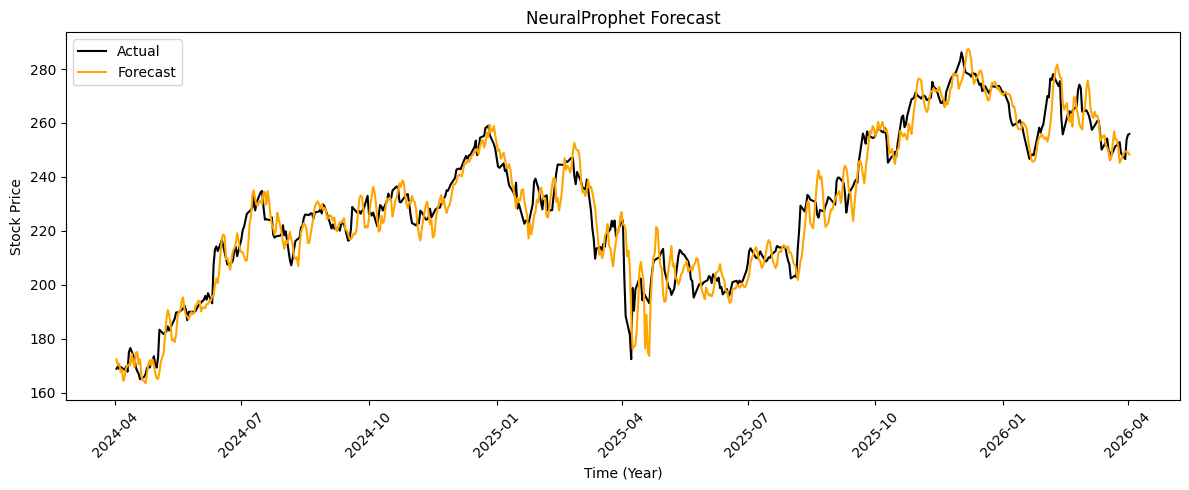

In [19]:
ds_test = test_df["ds"].iloc[:len(y_true)]

plt.figure(figsize=(12,5))

plt.plot(ds_test, y_true, label="Actual", color="black")
plt.plot(ds_test, y_pred, label="Forecast", color="orange")

plt.title("NeuralProphet Forecast")
plt.xlabel("Time (Year)")
plt.ylabel("Stock Price")

plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()